In [1]:
from baselines.Custom import ippo_ff_mpe
from baselines.Custom.simple_spread_visualizer import MPEVisualizer
import importlib.resources as resources
import yaml
from omegaconf import OmegaConf
import os
os.environ["WANDB_NOTEBOOK_NAME"] = "Playground.ipynb"
import jaxmarl
from jaxmarl.environments.mpe.simple_spread import SimpleSpreadMPE
from jaxmarl.wrappers.baselines import MPELogWrapper
from baselines.Custom.ippo_ff_mpe import ActorCritic 



In [2]:
import jax
import jaxlib
import flax

print(jax.devices())
print("JAX version:", jax.__version__)
print("JAXlib version:", jaxlib.__version__)
print("Flax version:", flax.__version__)


[CudaDevice(id=0)]
JAX version: 0.4.38
JAXlib version: 0.4.38
Flax version: 0.10.1


In [3]:
algo_and_config_map = {
    "ippo_ff_mpe": (ippo_ff_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "ippo_ff_mpe_simple_spread.yaml"))
}

In [4]:
%%time
ALGO_NAME = "ippo_ff_mpe"
algo, config = algo_and_config_map[ALGO_NAME]

CPU times: user 3 μs, sys: 2 μs, total: 5 μs
Wall time: 9.54 μs


In [5]:

config['TOTAL_TIMESTEPS'] = 5000
config

{'LR': 0.00025, 'NUM_ENVS': 16, 'NUM_STEPS': 128, 'TOTAL_TIMESTEPS': 5000, 'UPDATE_EPOCHS': 4, 'NUM_MINIBATCHES': 4, 'GAMMA': 0.99, 'GAE_LAMBDA': 0.95, 'CLIP_EPS': 0.2, 'ENT_COEF': 0.01, 'VF_COEF': 0.5, 'MAX_GRAD_NORM': 0.5, 'ACTIVATION': 'tanh', 'ENV_NAME': 'MPE_simple_spread_v3', 'ENV_KWARGS': {'num_landmarks': 3, 'num_agents': 3}, 'ANNEAL_LR': True, 'SEED': 30, 'NUM_SEEDS': 10, 'ENTITY': 'emiecz-princeton', 'PROJECT': 'ScalingLaws', 'WANDB_MODE': 'offline', 'RUN_NAME': 'ippo-ff-simple-spread_3_landmarks_3_agents'}

In [ ]:
import time
for num_agents in range(2,8):
    for num_landmarks in range(3,4):
        start = time.time()
        config["ENV_KWARGS"]["num_agents"] = num_agents
        config["ENV_KWARGS"]["num_landmarks"] = num_landmarks
        config['RUN_NAME'] = f"ippo-ff-simple-spread_{num_landmarks}_landmarks_{num_agents}_agents" 
        
        print(f"Running MPE Training with run name {config['RUN_NAME']}, and config {config['ENV_KWARGS']}")
        algo.main(config)
        print(f"Finished in {time.time()-start}")

wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find Playground.ipynb.


Running MPE Training with run name ippo-ff-simple-spread_3_landmarks_2_agents, and config {'num_landmarks': 3, 'num_agents': 2}


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


actor_loss,▁▅▅▃▅▃▃▃▄▄▆█▇▇▇▆██▇▆
critic_loss,█▂▃▅▆▆▂▅▇▆▂▄▄▅▆▃▂▂▁▇
entropy,▇█████▇▇██▁▅▃▃▅▃▂▂▄▃
ratio,▆▃█▇█▂▁▁▄▆█▆▇▆▆▆▆▅▆▄
ratio0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
returned_episode,▁▁▁▁▁▁▁▁▁▁██████████
returned_episode_lengths,▁▁▁▁▁▁▁▁▁▁██████████
returned_episode_returns,▆██▇▆▇▇▇▆▇▃▃▁▂▁▃▃▃▄▂
returns,▁
total_loss,█▂▃▅▆▆▂▅▇▆▂▄▄▅▆▃▂▂▁▇
actor_loss,-0.00046


Finished in 23.626030921936035
Running MPE Training with run name ippo-ff-simple-spread_3_landmarks_3_agents, and config {'num_landmarks': 3, 'num_agents': 3}


...

Finished in 19.558003187179565
Running MPE Training with run name ippo-ff-simple-spread_3_landmarks_4_agents, and config {'num_landmarks': 3, 'num_agents': 4}


actor_loss,▄▄▂▄▄▅▁▁▃▃█▇▆▆▇▇██▆█
critic_loss,▃▅▄▆▄▇▇▄▂▃▁▂▅▇▅▄▃▂█▁
entropy,▇▇▇▇██▇▇▇▇▅▄▁▄▆▆▁▁▂▄
ratio,▅▄▃▇▃▁█▃▆▃▄▄▃▅▄▃▄▅▅▄
ratio0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
returned_episode,▁▁▁▁▁▁▁▁▁▁██████████
returned_episode_lengths,▁▁▁▁▁▁▁▁▁▁██████████
returned_episode_returns,█▇█▇▇▇▆██▇▄▃▂▁▂▃▃▃▂▄
returns,▁
total_loss,▃▅▄▆▄▇▇▄▂▃▁▂▅▇▅▄▃▂█▁
actor_loss,-0.00012


Finished in 19.90655517578125
Running MPE Training with run name ippo-ff-simple-spread_3_landmarks_5_agents, and config {'num_landmarks': 3, 'num_agents': 5}


actor_loss,▁▅▃▁▁▃▅▅▅▄▄███▇█▇██▇
critic_loss,▃▃▃▂█▃▆▁▅▄▄▂▃▃▇▄▂▇▇▄
entropy,▇█▇▇▇▇████▁▆▃▂▂▄▅▆▇▅
ratio,▅█▇▂▃▁▂▇▅▄▆▅▄▃▄▄▃▄▄▆
ratio0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
returned_episode,▁▁▁▁▁▁▁▁▁▁██████████
returned_episode_lengths,▁▁▁▁▁▁▁▁▁▁██████████
returned_episode_returns,▇▇▇█▆▇▆▇▆▇▂▂▂▂▁▃▂▂▁▂
returns,▁
total_loss,▃▃▃▂█▃▆▁▅▄▄▂▃▃▇▄▂▇▇▄
actor_loss,-0.00017


Finished in 21.21950054168701
Running MPE Training with run name ippo-ff-simple-spread_3_landmarks_6_agents, and config {'num_landmarks': 3, 'num_agents': 6}


In [23]:
saved_path = "ippo_ff_mpe-offline/agents3-landmarks3/wandb"
saved_path = Path(saved_path)
saved_path = list(saved_path.glob("offline-run*"))[0]

In [24]:
saved_path

PosixPath('ippo_ff_mpe-offline/agents3-landmarks3/wandb/offline-run-20251112_110927-gb2e161z')

In [25]:
from baselines.Custom.ippo_ff_mpe import load_params_from_path
saved_path = "ippo_ff_mpe-offline/agents3-landmarks3/wandb"
saved_path = Path(saved_path)
saved_path = list(saved_path.glob("offline-run*"))[0]
params, env_config = load_params_from_path(saved_path)

Loading model parameters from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents3-landmarks3/wandb/offline-run-20251112_110927-gb2e161z/files/final_model_params.msgpack
Loading environment config from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents3-landmarks3/wandb/offline-run-20251112_110927-gb2e161z/files/env_config.json


Loading model parameters from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents3-landmarks3/wandb/offline-run-20251112_105407-ybrp8y49/files/final_model_params.msgpack
Loading environment config from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents3-landmarks3/wandb/offline-run-20251112_105407-ybrp8y49/files/env_config.json
Environment config: num_agents=3, num_landmarks=3
Running episode 1/1...
Creating visualization...
Comm active?  False
Visualization complete!


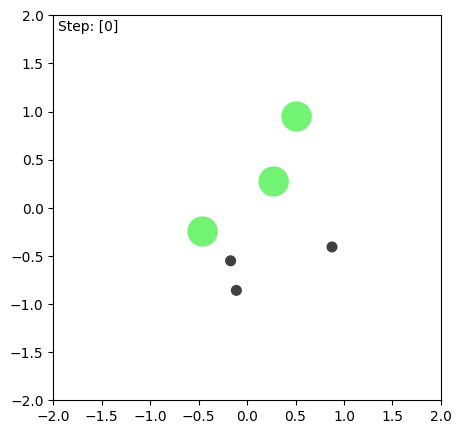

In [2]:
from baselines.Custom.ippo_ff_mpe import plot_simulation, evaluate_policy
plot_simulation(saved_path, num_episodes=1)

In [3]:
evaluate_policy(params,env_config, num_eval_episodes=10)

({'mean_return': -573.9442291259766,
  'std_return': 174.62498985996018,
  'min_return': -964.1395263671875,
  'max_return': -340.7308044433594,
  'median_return': -577.3290100097656,
  'mean_episode_length': 100.0,
  'std_episode_length': 0.0,
  'num_episodes': 10,
  'max_steps': 100},
 array([-678.48632812, -964.13952637, -340.73080444, -649.39837646,
        -449.10137939, -680.27282715, -412.73898315, -546.76086426,
        -409.91604614, -607.89715576]),
 array([100, 100, 100, 100, 100, 100, 100, 100, 100, 100]))

### Testing Many options

In [26]:
from pathlib import Path
from baselines.Custom.ippo_ff_mpe import load_params_from_path
import re

# Find all agent-landmark configuration folders
base_path = Path("ippo_ff_mpe-offline")
pattern = re.compile(r"agents(\d+)-landmarks(\d+)")

# Dictionary to store all loaded models
loaded_models = {}

if base_path.exists():
    for config_folder in sorted(base_path.iterdir()):
        if config_folder.is_dir():
            match = pattern.match(config_folder.name)
            if match:
                num_agents = int(match.group(1))
                num_landmarks = int(match.group(2))
                
                # Look for wandb/offline-run* directory
                wandb_path = config_folder / "wandb"
                wandb_path = Path(wandb_path)
                wandb_path = list(wandb_path.glob("offline-run*"))[0]
                wandb_path = wandb_path
                
                if wandb_path.exists():
                    try:
                        # Load params and config
                        params, env_config = load_params_from_path(wandb_path)
                        
                        # Store in dictionary with tuple key
                        key = (num_agents, num_landmarks)
                        loaded_models[key] = {
                            'params': params,
                            'env_config': env_config,
                            'path': str(wandb_path)
                        }
                        
                        print(f"✓ Loaded model: {num_agents} agents, {num_landmarks} landmarks")
                    except Exception as e:
                        print(f"✗ Failed to load {config_folder.name}: {e}")
                else:
                    print(f"✗ No wandb/latest-run found in {config_folder.name}")
    
    print(f"\n{'='*70}")
    print(f"Total models loaded: {len(loaded_models)}")
    print(f"Configurations: {sorted(loaded_models.keys())}")
    print(f"{'='*70}")
else:
    print(f"Error: {base_path} directory not found")

Loading model parameters from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents2-landmarks3/wandb/offline-run-20251112_110900-iw39lmmd/files/final_model_params.msgpack
Loading environment config from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents2-landmarks3/wandb/offline-run-20251112_110900-iw39lmmd/files/env_config.json
✓ Loaded model: 2 agents, 3 landmarks
Loading model parameters from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents3-landmarks3/wandb/offline-run-20251112_110927-gb2e161z/files/final_model_params.msgpack
Loading environment config from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents3-landmarks3/wandb/offline-run-20251112_110927-gb2e161z/files/env_config.json
✓ Loaded model: 3 agents, 3 landmarks
Loading model parameters from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents4-landmarks3/wandb/offline-run-20251112_110951-1q7qz5fm/files/final_model_params.msgpack
Loading environment config from: /home/dbraga/JaxMARL/ippo_ff_mpe-offline/agents4-landmarks3/wandb/offline-

In [27]:
from baselines.Custom.ippo_ff_mpe import evaluate_policy
evaluated_models = {}
for key, value in loaded_models.items():
    if key[1] != 3:
        continue
    print(f"Evaluating model with {key[0]} agents and {key[1]} landmarks...")
    eval_metrics, returns, lengths = evaluate_policy(value['params'], value['env_config'], num_eval_episodes=5, max_steps=40)
    evaluated_models[key] = {
        'eval_metrics': eval_metrics,
        'returns': returns,
        'lengths': lengths
    }

Evaluating model with 2 agents and 3 landmarks...
Evaluating model with 3 agents and 3 landmarks...
Evaluating model with 4 agents and 3 landmarks...
Evaluating model with 5 agents and 3 landmarks...
Evaluating model with 6 agents and 3 landmarks...
Evaluating model with 7 agents and 3 landmarks...


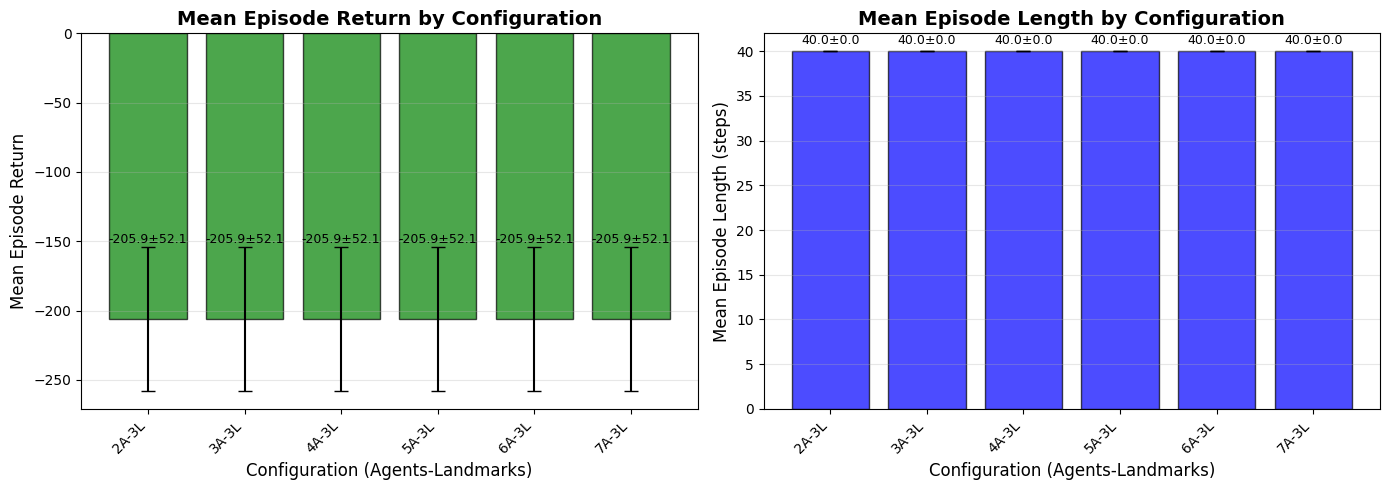


EVALUATION SUMMARY
Config          Mean Return          Mean Episode Length      
--------------------------------------------------------------------------------
2A-3L           -205.89 ± 52.11         40.0 ± 0.0
3A-3L           -205.89 ± 52.11         40.0 ± 0.0
4A-3L           -205.89 ± 52.11         40.0 ± 0.0
5A-3L           -205.89 ± 52.11         40.0 ± 0.0
6A-3L           -205.89 ± 52.11         40.0 ± 0.0
7A-3L           -205.89 ± 52.11         40.0 ± 0.0


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data for plotting
configs = sorted(evaluated_models.keys())
mean_returns = [evaluated_models[k]['eval_metrics']['mean_return'] for k in configs]
std_returns = [evaluated_models[k]['eval_metrics']['std_return'] for k in configs]
mean_lengths = [evaluated_models[k]['eval_metrics']['mean_episode_length'] for k in configs]
std_lengths = [evaluated_models[k]['eval_metrics']['std_episode_length'] for k in configs]

# Create labels for x-axis
labels = [f"{agents}A-{landmarks}L" for agents, landmarks in configs]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean Return with error bars
x_pos = np.arange(len(labels))
ax1.bar(x_pos, mean_returns, yerr=std_returns, capsize=5, alpha=0.7, color='green', edgecolor='black')
ax1.set_xlabel('Configuration (Agents-Landmarks)', fontsize=12)
ax1.set_ylabel('Mean Episode Return', fontsize=12)
ax1.set_title('Mean Episode Return by Configuration', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(mean_returns, std_returns)):
    ax1.text(i, mean + std + 0.5, f'{mean:.1f}±{std:.1f}', 
             ha='center', va='bottom', fontsize=9)

# Plot 2: Mean Episode Length with error bars
ax2.bar(x_pos, mean_lengths, yerr=std_lengths, capsize=5, alpha=0.7, color='blue', edgecolor='black')
ax2.set_xlabel('Configuration (Agents-Landmarks)', fontsize=12)
ax2.set_ylabel('Mean Episode Length (steps)', fontsize=12)
ax2.set_title('Mean Episode Length by Configuration', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(mean_lengths, std_lengths)):
    ax2.text(i, mean + std + 0.5, f'{mean:.1f}±{std:.1f}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)
print(f"{'Config':<15} {'Mean Return':<20} {'Mean Episode Length':<25}")
print("-"*80)
for key in configs:
    agents, landmarks = key
    metrics = evaluated_models[key]['eval_metrics']
    print(f"{agents}A-{landmarks}L{'':<10} "
          f"{metrics['mean_return']:.2f} ± {metrics['std_return']:.2f}{'':<8} "
          f"{metrics['mean_episode_length']:.1f} ± {metrics['std_episode_length']:.1f}")
print("="*80)